In [ ]:
class Dog:
   name = ""
   age = 0

# creating new instance of a dog
dog1 = Dog()
dog1.name = "Sheru"
dog1.age = 5

print(dog1.name)
print(dog1.age)


Sheru
5


In [ ]:
dog2 = Dog()
dog2.name = "Chadda"
dog2.age = 7

print(dog2.name)
print(dog2.age)

Chadda
7


In [ ]:
class Book:
  def __init__(self, title, author): # first method that will be called by default when the instance/object is created, self method means it is calling the instance/object itself, book will be called in our case
    self.title = title
    self.author = author
    self.price = 0
    self.discount = 0

  def print_info(self):
    print(f"Title: {self.title}")
    print(f"Author: {self.author}")

  def set_price(self, price):
    self.price = price

  def set_discount(self, discount):
    self.discount = discount

  def get_price(self):
    if self.discount > 0:
      return self.price * (1 - self.discount)
    else:
      return self.price

book1 = Book("The Alchemist", "Paulo Coelho")
# print(book1.title)
# print(book1.author)
book1.print_info()
book1.set_price(100)
print(f"Before Discount: {book1.get_price()}")
book1.set_discount(0.4)
print(f"After Discount: {book1.get_price()}")
print(book1.get_price())

Title: The Alchemist
Author: Paulo Coelho
Before Discount: 100
After Discount: 60.0
60.0


In [ ]:
# lists

var1 = [2,4,6]
print(type(var1))

<class 'list'>


In [ ]:
var1.append(10)
print(var1)

[2, 4, 6, 10]


Novels -> genre, Storyline, language
Textbook -> subject, abstract

In [ ]:
class Novel(Book):
  def __init__(self, title, author, genre, storyline, language):
    super().__init__(title, author)
    self.genre = genre
    self.storyline = storyline
    self.language = language

  def print_info(self):
    super().print_info()
    print(f"Price: {self.price}")
    print(f"Discount: {self.discount}")
    print(f"Genre: {self.genre}")
    print(f"Storyline: {self.storyline}")
    print(f"Language: {self.language}")

novel1 = Novel("Despicable Me", "Gru&Minions", "Comedy&Thriller", "Villian", "English")
novel1.print_info()

Title: Despicable Me
Author: Gru&Minions
Price: 0
Discount: 0
Genre: Comedy&Thriller
Storyline: Villian
Language: English


In [ ]:
novel1.set_price(200)
novel1.set_discount(0.2)
novel1.print_info()

Title: Despicable Me
Author: Gru&Minions
Price: 200
Discount: 0.2
Genre: Comedy&Thriller
Storyline: Villian
Language: English


In [ ]:
class Textbook(Book):
  def __init__(self, title, author, subject, abstract):
    super().__init__(title, author)
    self.subject = subject
    self.abstract = abstract

  def print_abstract(self):
    print(f"Abstract: {self.abstract}")
    print(f"Subject: {self.subject}")

text1 = Textbook("Dive into Deep Learning", "Ashton Kusher", "Deep Learning", "Deep Leanring Approach")
text1.print_abstract()

Abstract: Deep Leanring Approach
Subject: Deep Learning


In [ ]:
text1.print_info()

Title: Dive into Deep Learning
Author: Ashton Kusher


In [1]:
# read the csv and creating the dataframe

import pandas as pd
import numpy as np

# Generate random data for each column
num_books = 10  # You can change the number of books
titles = ['Book ' + str(i) for i in range(1, num_books + 1)]
authors = ['Author ' + str(i) for i in range(1, num_books + 1)]
prices = np.random.randint(10, 50, size=num_books)  # Random prices between 10 and 50
ratings = np.random.randint(1, 6, size=num_books)  # Random ratings between 1 and 5

# Create a dictionary with the data
data = {
    'Title': titles,
    'Author': authors,
    'Price': prices,
    'Rating': ratings
}

# Create a Pandas DataFrame
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file named 'books.csv'
df.to_csv('books.csv', index=False)  # index=False prevents writing row indices to the file

# Now you can read the CSV file into a DataFrame:
df_loaded = pd.read_csv('books.csv')
df_loaded.head()  # Display the first few rows of the DataFrame

,Title,Author,Price,Rating
0,Book 1,Author 1,39,1
1,Book 2,Author 2,13,5
2,Book 3,Author 3,45,1
3,Book 4,Author 4,22,4
4,Book 5,Author 5,36,4


In [5]:
# create an instance of  Linear Regression

from sklearn.linear_model import LinearRegression
model = LinearRegression()

# train the model

model.fit(df_loaded[["Rating"]], df_loaded["Price"])

LinearRegression()

In [6]:
df_loaded.describe()

,Price,Rating
count,10.000000,10.00000
mean,26.000000,2.90000
std,13.556466,1.72884
min,10.000000,1.00000
25%,13.500000,1.00000
50%,23.000000,3.50000
75%,38.250000,4.00000
max,45.000000,5.00000


In [10]:
# test the model

predict = model.predict(df_loaded[["Rating"]])

In [11]:
# print the mse error

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df_loaded["Price"], predict)
print(mse)

165.36654275092934


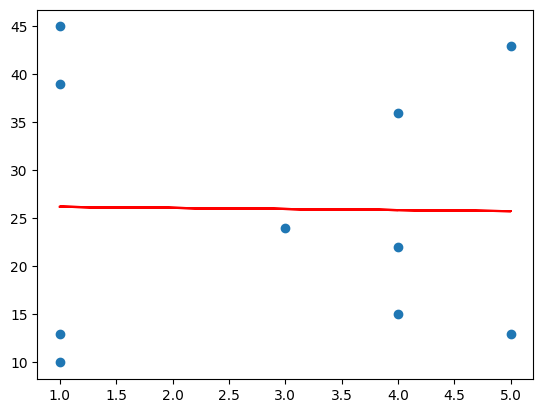

In [12]:
# plot the trained data

import matplotlib.pyplot as plt
plt.scatter(df_loaded["Rating"], df_loaded["Price"])
plt.plot(df_loaded["Rating"], predict, color="red")
plt.show()

Mean Squared Error: 0.012766173238957207


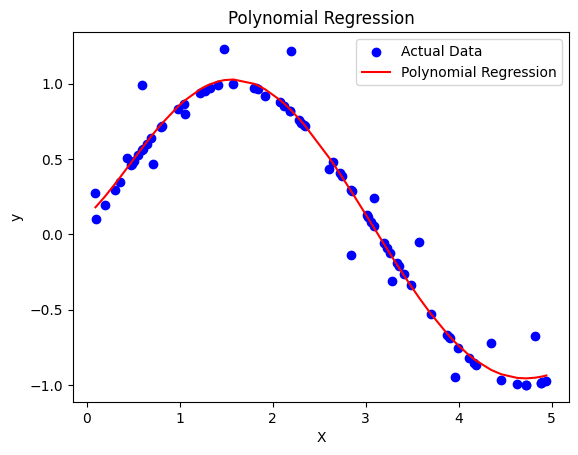

In [13]:
# prompt: create a data as csv to check for polynomial regression and also calculate the mse and also plot the data.

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generate sample data (replace with your actual data)
np.random.seed(0)  # for reproducibility
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 1 * (0.5 - np.random.rand(16))  # Add some noise

# Create polynomial features
poly = PolynomialFeatures(degree=5)  # Adjust the degree as needed
X_poly = poly.fit_transform(X)

# Fit polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly, y)

# Make predictions
y_pred = poly_reg_model.predict(X_poly)

# Calculate MSE
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

# Plot the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()


# Create a DataFrame for the data
data = {'X': X.flatten(), 'y': y}
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('polynomial_regression_data.csv', index=False)